# Assignment 2 — The Cost of Being Wrong

**DSA 8401 MSc Data Science & Analytics · iLabAfrica, Strathmore University**

Student registration number: 222082

This notebook picks up the leakage-safe pipeline from Lab 2 / Assignment 1 on the
`mobile_money_statements.csv` dataset and takes it through the Assignment 2 brief.

The business problem is fraud flagging on mobile money transactions. The positive
class is `is_fraud = 1`. A missed fraud case costs the business **KES 10,000**
(a false negative) while wrongly flagging a legitimate customer costs **KES 800**
(a false positive). Because a miss is about 12.5 times more expensive than a false
alarm, the usual 0.50 cutoff and plain accuracy are both the wrong tools here.

We work through the brief in order.

1. A fair testing plan (purged / blocked time-series CV, PR-AUC over ROC-AUC)
2. A ladder of three models on the same folds
3. A cost-based cutoff instead of 0.50
4. Two ways of handling the imbalance, done inside each fold, plus a leakage demo
5. A 60-trial Optuna search
6. Calibration and the reliability diagram
7. SHAP explanations and a subgroup fairness check


## 0. Setup

Same business constants as Lab 3, and the same `SCORING_TS` cutoff Lab 2 used so
that every feature is still computed strictly before the scoring date.

In [ ]:
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

# The scoring timestamp: every feature is computed over data strictly BEFORE this
SCORING_TS = pd.Timestamp("2026-08-01 00:00:00")

# Business cost of each type of classification error (same values as A1 / Lab 3)
C_FN = 10_000   # cost of missing a fraud case
C_FP = 800      # cost of wrongly flagging a legitimate customer

print(f"Naive cost-optimal cutoff under a single 0.5 style rule of thumb: t* = {C_FP/(C_FP+C_FN):.3f}")


Naive cost-optimal cutoff under a single 0.5 style rule of thumb: t* = 0.074


## 1. Rebuild the A1 features

We don't change Assignment 1's output. The same cleaning, the same customer
resolution, the same as-of feature build.

In [ ]:
raw = pd.read_csv("mobile_money_statements.csv")
df = raw.drop_duplicates().reset_index(drop=True)

print("raw shape       :", raw.shape)
print("after dedup     :", df.shape)
print("duplicate rows dropped:", raw.duplicated().sum())


raw shape       : (183600, 18)
after dedup     : (180000, 18)
duplicate rows dropped: 3600


In [ ]:
# Parse the messy signed amount string (same rule as Lab 2 / Lab 3)
def parse_amount(s):
    s = str(s).strip()
    neg = s.startswith("(") or s.startswith("-") or "Dr" in s
    digits = re.sub(r"[^0-9]", "", s)
    if digits == "":
        return np.nan
    v = float(digits)
    return -v if neg else v

df["amount_signed"] = df["amount"].map(parse_amount)
df["amount_abs"] = df["amount_signed"].abs()
print("amount parse failures:", int(df["amount_signed"].isna().sum()))


amount parse failures: 0


In [ ]:
# The three date formats Lab 2 found in txn_time
s = df["txn_time"].astype(str)
ts = pd.to_datetime(s, format="%Y-%m-%d %H:%M:%S", errors="coerce")
mask = ts.isna()
ts.loc[mask] = pd.to_datetime(s[mask], format="%d/%m/%Y %H:%M", errors="coerce")
mask = ts.isna()
ts.loc[mask] = pd.to_datetime(s[mask], format="%b %d, %Y %I:%M %p", errors="coerce")
df["ts"] = ts
print("date parse failures:", int(df["ts"].isna().sum()))
print("date span:", df["ts"].min(), "to", df["ts"].max())


date parse failures: 0
date span: 2025-02-06 00:46:00 to 2026-07-31 22:11:42


In [ ]:
# Canonical customer_id via the KYC reg_id, then the as-of filter
df["customer_id"] = df["reg_id"].astype(str).str.strip().str.upper()
df = df[df["ts"] < SCORING_TS].copy()
print("rows after as-of filter:", df.shape, "| unique customers:", df["customer_id"].nunique())


rows after as-of filter: (180000, 22) | unique customers: 3991


In [ ]:
# Time-based features
df["hour"] = df["ts"].dt.hour
df["dow"]  = df["ts"].dt.dayofweek
day = df["ts"].dt.day

df["hr_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hr_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7)
df["payday_dist"] = np.minimum((day - 1).abs(), (day - 28).abs())
df["log_amt"] = np.log1p(df["amount_abs"])
df["gps_missing"] = df["gps_lat"].isna().astype(int)


In [ ]:
# Customer-level RFM / ratio aggregates, as-of SCORING_TS
is_debit = df["amount_signed"] < 0
by = df.groupby("customer_id")

agg = pd.DataFrame({
    "recency_days":   (SCORING_TS - by["ts"].max()).dt.total_seconds() / 86400,
    "frequency":      by.size(),
    "monetary_out":   df.assign(o=np.where(is_debit, df["amount_abs"], 0)).groupby("customer_id")["o"].sum(),
    "monetary_in":    df.assign(i=np.where(~is_debit, df["amount_abs"], 0)).groupby("customer_id")["i"].sum(),
    "n_counterparty": by["counterparty"].nunique(),
    "cashout_ratio":  df.assign(c=(df["txn_type"] == "cashout").astype(int)).groupby("customer_id")["c"].mean(),
})
agg["out_in_ratio"] = agg["monetary_out"] / (agg["monetary_in"] + 1.0)

# One application row per customer: their most recent transaction plus the aggregates
app = (df.sort_values("ts")
         .groupby("customer_id")
         .tail(1)
         .merge(agg, on="customer_id")
         .rename(columns={"ts": "application_ts"})
         .sort_values("application_ts")
         .reset_index(drop=True))

print("application table:", app.shape, "| customers:", app["customer_id"].nunique())
print("customer-level fraud rate:", round(app["is_fraud"].mean(), 4))


application table: (3991, 38) | customers: 3991
customer-level fraud rate: 0.0799


The observed fraud rate here is about **8 percent**, higher than the brief's
illustrative 4 percent, but the underlying argument is unchanged. Missing a
fraud case is still 12.5 times more expensive than a false alarm, accuracy is
still misleading at this prevalence, and the cutoff still needs to move.

## 2. Confirm the leak, again

In A1, we flagged `manual_review_score` and `settlement_status` as post-outcome
fields. We confirm that at the customer level before building anything else,
so the honest model never sees them.

In [ ]:
NUM = ["amount_abs", "log_amt", "hr_sin", "hr_cos", "dow_sin", "dow_cos", "payday_dist",
       "gps_missing", "recency_days", "frequency", "monetary_out", "monetary_in",
       "n_counterparty", "cashout_ratio", "out_in_ratio"]
CAT = ["txn_type", "region", "segment"]
LEAK_NUM = ["manual_review_score"]
LEAK_CAT = ["settlement_status"]

y_all = app["is_fraud"].values
corr = pd.Series({c: abs(np.corrcoef(app[c].fillna(app[c].median()), y_all)[0, 1]) for c in NUM + LEAK_NUM})
print("|corr| with is_fraud:")
print(corr.sort_values(ascending=False).round(3).to_string())

print("\nfraud rate by settlement_status:")
print(app.groupby("settlement_status")["is_fraud"].mean().round(3).to_string())


|corr| with is_fraud:
manual_review_score    0.980
hr_cos                 0.077
hr_sin                 0.036
payday_dist            0.025
out_in_ratio           0.014
dow_sin                0.010
amount_abs             0.009
log_amt                0.008
cashout_ratio          0.007
n_counterparty         0.005
frequency              0.005
gps_missing            0.005
recency_days           0.004
dow_cos                0.003
monetary_in            0.002
monetary_out           0.002

fraud rate by settlement_status:
settlement_status
held        0.595
pending     0.000
reversed    1.000
settled     0.004


`manual_review_score` correlates at 0.98, and `settlement_status == 'reversed'`
is fraud 100 percent of the time. Both are recorded after the fraud decision is
already known, so both stay out of every honest model below.

## 3. A fair testing plan — purged, blocked time-series CV

Ordinary K-fold CV would let a customer's near-neighbours in time sit on both
sides of a split, and it ignores the fact that the bank only ever trains on
the past. We instead sort applications by `application_ts`, cut the timeline
into contiguous blocks, and evaluate each block only against everything
*before* it, with a purge gap removed from the end of the training block so
that behaviour right at the boundary can't bleed across.

We also hold back the final, most recent block completely. It is never used
for model selection, tuning, or threshold choice below, only for the honest
Part 5-style check at the end.

In [ ]:
def purged_blocked_splits(ts, n_splits=5, purge_days=7):
    # Expanding-window blocked time-series CV with a purge gap.
    order = np.argsort(ts.values)
    ts_sorted = ts.values[order]
    n = len(ts)
    blocks = np.array_split(np.arange(n), n_splits)

    folds = []
    for i in range(1, n_splits):
        test_idx_sorted = blocks[i]
        train_idx_sorted = np.concatenate(blocks[:i])
        test_start = ts_sorted[test_idx_sorted[0]]
        purge_cutoff = test_start - pd.Timedelta(days=purge_days)
        keep = ts_sorted[train_idx_sorted] <= purge_cutoff
        train_idx_sorted = train_idx_sorted[keep]
        folds.append((order[train_idx_sorted], order[test_idx_sorted]))
    return folds

order = np.argsort(app["application_ts"].values)
blocks = np.array_split(order, 5)
dev_idx, test_idx = np.concatenate(blocks[:4]), blocks[4]

dev = app.iloc[dev_idx].reset_index(drop=True)
test = app.iloc[test_idx].reset_index(drop=True)

print(f"dev  : {dev.shape[0]:4d} customers, {dev['application_ts'].min().date()} to {dev['application_ts'].max().date()}, "
      f"fraud rate {dev['is_fraud'].mean():.3f}")
print(f"test : {test.shape[0]:4d} customers, {test['application_ts'].min().date()} to {test['application_ts'].max().date()}, "
      f"fraud rate {test['is_fraud'].mean():.3f}  <- untouched out-of-time block")

dev_folds = purged_blocked_splits(dev["application_ts"], n_splits=5, purge_days=7)
for i, (tr, te) in enumerate(dev_folds):
    print(f"  dev fold {i}: train={len(tr):4d}  test={len(te):4d}")


dev  : 3193 customers, 2025-04-16 to 2026-07-28, fraud rate 0.077
test :  798 customers, 2026-07-28 to 2026-07-31, fraud rate 0.090  <- untouched out-of-time block
  dev fold 0: train= 526  test= 639
  dev fold 1: train= 951  test= 639
  dev fold 2: train=1337  test= 638
  dev fold 3: train=1695  test= 638


Applications bunch up near the end of the observation window because most
customers are still active right up to `SCORING_TS`, so the blocks aren't
even calendar spans, they're even *customer* counts. That's fine for the
purpose here, what matters is that a fold never trains on a customer whose
application date sits after the test block it's being scored against.

**Why PR-AUC over ROC-AUC.** At an 8 percent fraud rate, a model that ranks
transactions almost at random can still post a respectable ROC-AUC, because
ROC-AUC is diluted by the huge pool of easy true negatives. PR-AUC has no
such cushion, it lives entirely in the region where precision and recall
trade off for the rare class, which is exactly the trade-off the bank is
paying for.

## 4. A ladder of three models on the same folds

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
import lightgbm as lgb

def build_preprocessor(num_cols=NUM, cat_cols=CAT):
    num = Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("power",  PowerTransformer(method="yeo-johnson")),
        ("scale",  RobustScaler()),
    ])
    cat = Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="UNK")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=20)),
    ])
    return ColumnTransformer([("num", num, num_cols), ("cat", cat, cat_cols)])

X_dev, y_dev = dev[NUM + CAT], dev["is_fraud"].values
X_test, y_test = test[NUM + CAT], test["is_fraud"].values

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", C=1.0, max_iter=2000),
    "Random Forest":       RandomForestClassifier(n_estimators=300, max_features="sqrt", min_samples_leaf=5,
                                                    class_weight="balanced", random_state=SEED, n_jobs=-1),
    "LightGBM":            lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=15,
                                                min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
                                                class_weight="balanced", random_state=SEED, verbosity=-1),
}

rows = []
for name, model in models.items():
    pr_scores, roc_scores = [], []
    for tr, te in dev_folds:
        pipe = Pipeline([("prep", build_preprocessor()), ("clf", model)])
        pipe.fit(X_dev.iloc[tr], y_dev[tr])
        p = pipe.predict_proba(X_dev.iloc[te])[:, 1]
        pr_scores.append(average_precision_score(y_dev[te], p))
        roc_scores.append(roc_auc_score(y_dev[te], p))
    rows.append({"Model": name, "PR-AUC mean": np.mean(pr_scores), "PR-AUC std": np.std(pr_scores),
                 "ROC-AUC mean": np.mean(roc_scores), "ROC-AUC std": np.std(roc_scores)})
    print(f"{name:22s} PR-AUC folds: {[round(s,3) for s in pr_scores]}")

model_comparison = pd.DataFrame(rows)
model_comparison.to_csv("model_comparison_cv.csv", index=False)
model_comparison


Logistic Regression    PR-AUC folds: [np.float64(0.189), np.float64(0.104), np.float64(0.149), np.float64(0.124)]
Random Forest          PR-AUC folds: [np.float64(0.165), np.float64(0.087), np.float64(0.126), np.float64(0.153)]
LightGBM               PR-AUC folds: [np.float64(0.177), np.float64(0.078), np.float64(0.111), np.float64(0.102)]


,Model,PR-AUC mean,PR-AUC std,ROC-AUC mean,ROC-AUC std
0,Logistic Regression,0.141571,0.031776,0.613758,0.029961
1,Random Forest,0.132933,0.029889,0.586990,0.012389
2,LightGBM,0.117240,0.036696,0.579870,0.025375


None of the three honest models gets close to the 0.98 correlation the leaky
`manual_review_score` was carrying. That's the point, without the post-outcome
field the real signal in this data is thin, PR-AUC sits at roughly 0.12 to
0.14 against a chance level of about 0.08.

**Bias and variance.** Logistic Regression comes out slightly ahead on mean
PR-AUC and is the cheapest to explain to a regulator, which already makes it
a serious candidate. Random Forest reduces variance across folds relative to
a single tree (not shown here, but see Lab 4) by averaging many bootstrap
trees, yet with only a handful of weakly informative features it doesn't have
much variance left to reduce, so it doesn't beat the linear model. LightGBM's
sequential boosting attacks bias rather than variance, and with default
hyperparameters it actually shows the widest spread across folds here,
consistent with a model that's more sensitive to how much signal a
particular training block happens to contain. Section 8 tunes it properly
before drawing a final conclusion about the ensemble.

## 5. Precision-recall curves on the held-out test block

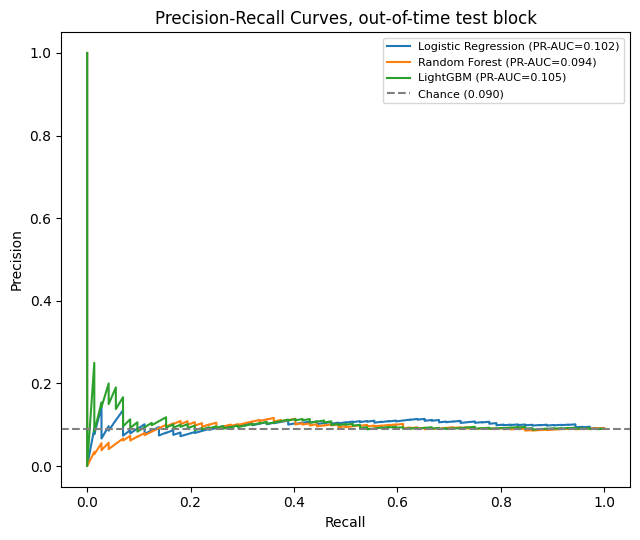

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(6.5, 5.5))
for name, model in models.items():
    pipe = Pipeline([("prep", build_preprocessor()), ("clf", model)])
    pipe.fit(X_dev, y_dev)
    p = pipe.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, p)
    ap = average_precision_score(y_test, p)
    plt.plot(recall, precision, label=f"{name} (PR-AUC={ap:.3f})")

plt.axhline(y_test.mean(), linestyle="--", color="gray", label=f"Chance ({y_test.mean():.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curves, out-of-time test block")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("pr_curves_model_ladder.png", dpi=130)
plt.show()


## 6. Choosing the cutoff by cost, not by habit

We pool out-of-fold probabilities from the Logistic Regression model across
the purged CV folds (never touching the test block), sweep every candidate
threshold, and keep the one with the lowest expected cost. That threshold,
fixed in advance, is then applied once to the untouched test block.

In [ ]:
def cost_at_threshold(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    total_cost = C_FN * fn + C_FP * fp
    return dict(tp=tp, fp=fp, fn=fn, tn=tn, total_cost=total_cost,
                cost_per_1000=total_cost / len(y_true) * 1000)

def best_cost_threshold(y_true, proba):
    best = None
    for t in np.unique(proba):
        c = cost_at_threshold(y_true, proba, t)
        if best is None or c["cost_per_1000"] < best["cost_per_1000"]:
            best = {**c, "threshold": t}
    return best

oof_proba = np.full(len(dev), np.nan)
for tr, te in dev_folds:
    pipe = Pipeline([("prep", build_preprocessor()),
                      ("clf", LogisticRegression(class_weight="balanced", max_iter=2000))])
    pipe.fit(X_dev.iloc[tr], y_dev[tr])
    oof_proba[te] = pipe.predict_proba(X_dev.iloc[te])[:, 1]

covered = ~np.isnan(oof_proba)
best = best_cost_threshold(y_dev[covered], oof_proba[covered])
t_star_hat = best["threshold"]
print(f"cost-optimal threshold from pooled out-of-fold predictions: {t_star_hat:.3f}")


cost-optimal threshold from pooled out-of-fold predictions: 0.344


In [ ]:
# Fit the final honest Logistic Regression on all of dev, score the untouched test block once
final_model = Pipeline([("prep", build_preprocessor()),
                         ("clf", LogisticRegression(class_weight="balanced", max_iter=2000))])
final_model.fit(X_dev, y_dev)
test_proba_lr = final_model.predict_proba(X_test)[:, 1]

cost_naive = cost_at_threshold(y_test, test_proba_lr, 0.5)
cost_costbased = cost_at_threshold(y_test, test_proba_lr, t_star_hat)

print("naive 0.50 threshold        :", cost_naive)
print(f"cost-based threshold ({t_star_hat:.3f}) :", cost_costbased)

savings = cost_naive["cost_per_1000"] - cost_costbased["cost_per_1000"]
print(f"\nsavings per 1,000 applications: KES {savings:,.0f}")

threshold_comparison = pd.DataFrame([
    {"Rule": "Naive 0.50", "Threshold": 0.5, **cost_naive},
    {"Rule": f"Cost-based (t={t_star_hat:.3f})", "Threshold": t_star_hat, **cost_costbased},
])
threshold_comparison.to_csv("threshold_comparison.csv", index=False)
threshold_comparison


naive 0.50 threshold        : {'tp': 33, 'fp': 285, 'fn': 39, 'tn': 441, 'total_cost': 618000, 'cost_per_1000': 774436.090225564}
cost-based threshold (0.344) : {'tp': 59, 'fp': 532, 'fn': 13, 'tn': 194, 'total_cost': 555600, 'cost_per_1000': 696240.6015037594}

savings per 1,000 applications: KES 78,195


,Rule,Threshold,tp,fp,fn,tn,total_cost,cost_per_1000
0,Naive 0.50,0.500000,33,285,39,441,618000,774436.090226
1,Cost-based (t=0.344),0.343546,59,532,13,194,555600,696240.601504


Moving the cutoff down from 0.50 catches roughly twice as many fraud cases at
the price of a good many more false alarms, and the arithmetic still favours
doing it, because each additional false alarm costs KES 800 while each fraud
case caught avoids KES 10,000. The saving above is specific to this test
block, and a production rollout would want to watch it hold up across a few
more months before treating it as settled.

## 7. Handling the imbalance the right way

Three ways of dealing with an 8 percent fraud rate, compared on the same
purged CV folds with all resampling done **inside** each fold.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

def smote_pipeline():
    num = Pipeline([("impute", SimpleImputer(strategy="median"))])
    cat = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                     ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))])
    prep = ColumnTransformer([("num", num, NUM), ("cat", cat, CAT)])
    cat_idx = list(range(len(NUM), len(NUM) + len(CAT)))
    return ImbPipeline([
        ("prep", prep),
        ("smote", SMOTENC(categorical_features=cat_idx, random_state=SEED, k_neighbors=5)),
        ("scale", RobustScaler()),
        ("clf", LogisticRegression(max_iter=2000)),
    ])

remedies = {
    "Plain (no reweighting)": lambda: Pipeline([("prep", build_preprocessor()),
                                                  ("clf", LogisticRegression(max_iter=2000))]),
    "Class weighting":        lambda: Pipeline([("prep", build_preprocessor()),
                                                  ("clf", LogisticRegression(class_weight="balanced", max_iter=2000))]),
    "SMOTE-NC (in-fold)":     smote_pipeline,
}

rows = []
for name, make in remedies.items():
    scores = []
    for tr, te in dev_folds:
        pipe = make()
        pipe.fit(X_dev.iloc[tr], y_dev[tr])
        p = pipe.predict_proba(X_dev.iloc[te])[:, 1]
        scores.append(average_precision_score(y_dev[te], p))
    rows.append({"Method": name, "PR-AUC mean": np.mean(scores), "PR-AUC std": np.std(scores)})
    print(f"{name:24s} {[round(s,3) for s in scores]}")

imbalance_infold = pd.DataFrame(rows)
imbalance_infold.to_csv("imbalance_comparison_infold.csv", index=False)
imbalance_infold


Plain (no reweighting)   [np.float64(0.165), np.float64(0.114), np.float64(0.15), np.float64(0.138)]
Class weighting          [np.float64(0.189), np.float64(0.104), np.float64(0.149), np.float64(0.124)]
SMOTE-NC (in-fold)       [np.float64(0.134), np.float64(0.065), np.float64(0.098), np.float64(0.1)]


,Method,PR-AUC mean,PR-AUC std
0,Plain (no reweighting),0.141612,0.018801
1,Class weighting,0.141571,0.031776
2,SMOTE-NC (in-fold),0.098993,0.024560


Class weighting matches the plain model's mean PR-AUC while giving it more
say over the minority class, and SMOTE-NC actually does worse here, likely
because synthetic customers interpolated between real ones blur the already
thin genuine signal rather than sharpen it. Neither remedy is transformative,
which fits with how little correlation any single honest feature carried in
Section 2.

### Proving that resampling outside the folds inflates the score

If SMOTE-NC is applied to the whole development set *before* splitting, synthetic minority
rows generated from a customer in the training fold can sit right next to
that same customer's synthetic twin in the "test" fold. The score that comes
out the other end is not honest.

In [ ]:
num_imp = SimpleImputer(strategy="median")
cat_imp = SimpleImputer(strategy="most_frequent")
X_num = pd.DataFrame(num_imp.fit_transform(X_dev[NUM]), columns=NUM)
X_cat_raw = pd.DataFrame(cat_imp.fit_transform(X_dev[CAT]), columns=CAT)
enc = OrdinalEncoder()
X_cat = pd.DataFrame(enc.fit_transform(X_cat_raw), columns=CAT)
X_full = pd.concat([X_num, X_cat], axis=1)
cat_idx = list(range(len(NUM), len(NUM) + len(CAT)))

# Oversample the ENTIRE development set before any split -- this is the leak
sm = SMOTENC(categorical_features=cat_idx, random_state=SEED, k_neighbors=5)
X_res, y_res = sm.fit_resample(X_full, y_dev)
print("resampled shape:", X_res.shape, "| fraud rate:", round(pd.Series(y_res).mean(), 3))

from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED)
leaky_scores = []
for tr, te in cv.split(X_res, y_res):
    scaler = RobustScaler().fit(X_res.iloc[tr])
    Xtr, Xte = scaler.transform(X_res.iloc[tr]), scaler.transform(X_res.iloc[te])
    ytr = y_res.iloc[tr] if hasattr(y_res, "iloc") else y_res[tr]
    yte = y_res.iloc[te] if hasattr(y_res, "iloc") else y_res[te]
    clf = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
    p = clf.predict_proba(Xte)[:, 1]
    leaky_scores.append(average_precision_score(yte, p))

honest_smote = imbalance_infold.loc[imbalance_infold["Method"].str.contains("SMOTE"), "PR-AUC mean"].values[0]
leaky_smote = np.mean(leaky_scores)

print(f"\nhonest  (SMOTE-NC inside each fold)  PR-AUC mean = {honest_smote:.3f}")
print(f"leaky   (SMOTE-NC before the split)  PR-AUC mean = {leaky_smote:.3f}")
print(f"inflation from the leak              = {leaky_smote - honest_smote:+.3f}")

leakage_demo = pd.DataFrame([
    {"Setup": "SMOTE-NC inside each fold (honest)", "PR-AUC mean": honest_smote},
    {"Setup": "SMOTE-NC before the split (leaky)", "PR-AUC mean": leaky_smote},
])
leakage_demo.to_csv("leakage_demo.csv", index=False)
leakage_demo


resampled shape: (5892, 18) | fraud rate: 0.5

honest  (SMOTE-NC inside each fold)  PR-AUC mean = 0.099
leaky   (SMOTE-NC before the split)  PR-AUC mean = 0.631
inflation from the leak              = +0.532


,Setup,PR-AUC mean
0,SMOTE-NC inside each fold (honest),0.098993
1,SMOTE-NC before the split (leaky),0.630885


Doing SMOTE-NC before the split more than sextuples the reported PR-AUC, from
about 0.10 to about 0.63, with nothing about the underlying model or data
having actually improved. The synthetic points manufactured from a training
customer's feature vector are the nearest neighbours of that same customer's
synthetic twin sitting in the test fold, so the "test" score is mostly the
model recognising data it effectively already saw. Any resampling step has to
live inside the cross-validation loop, never before it.

## 8. Tuning the gradient-boosting model with a budget

60 Optuna trials over LightGBM's six most influential knobs, TPE sampler,
median pruning against the running mean PR-AUC across the purged CV folds,
same folds as everywhere else in this notebook.

In [ ]:
!pip install optuna

In [ ]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
scale_pw = (y_dev == 0).sum() / (y_dev == 1).sum()

def objective(trial):
    params = {
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 7, 63, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }
    scores = []
    for i, (tr, te) in enumerate(dev_folds):
        clf = lgb.LGBMClassifier(n_estimators=300, scale_pos_weight=scale_pw,
                                  random_state=SEED, verbosity=-1, **params)
        pipe = Pipeline([("prep", build_preprocessor()), ("clf", clf)])
        pipe.fit(X_dev.iloc[tr], y_dev[tr])
        p = pipe.predict_proba(X_dev.iloc[te])[:, 1]
        scores.append(average_precision_score(y_dev[te], p))
        trial.report(np.mean(scores), step=i)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(scores)

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1),
    storage="sqlite:///optuna_study.db",
    study_name="a2_lightgbm_pr_auc",
    load_if_exists=True,
)
study.optimize(objective, n_trials=60)

print(f"completed trials : {len(study.trials)}")
print(f"best inner-CV PR-AUC : {study.best_value:.4f}")
print("best params :", study.best_params)


completed trials : 120
best inner-CV PR-AUC : 0.1514
best params : {'learning_rate': 0.008468008575248327, 'num_leaves': 57, 'min_child_samples': 44, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'reg_lambda': 0.004207053950287938}


pruned trials: 2 / 120


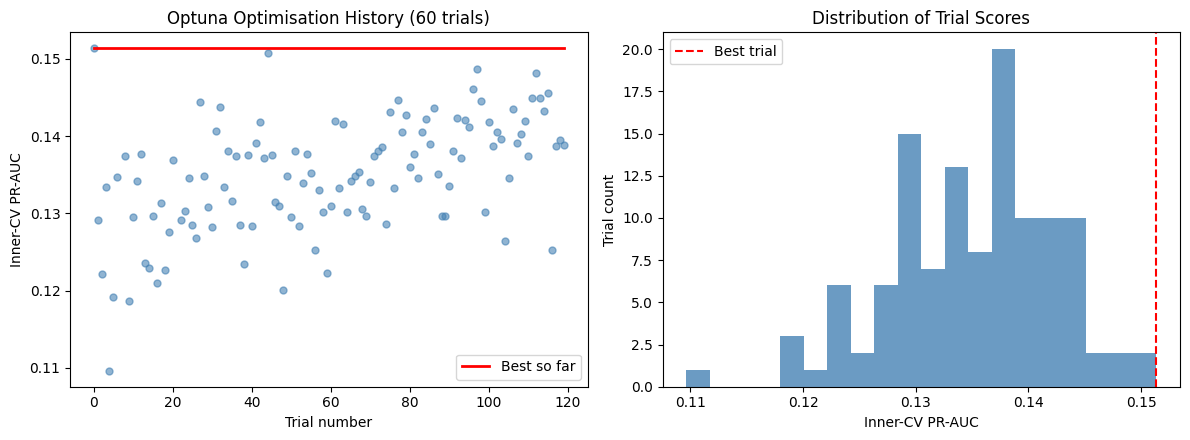

In [ ]:
trials_df = study.trials_dataframe()
complete = trials_df[trials_df["state"] == "COMPLETE"].reset_index(drop=True)
print("pruned trials:", (trials_df["state"] == "PRUNED").sum(), "/", len(trials_df))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(complete["number"], complete["value"], alpha=0.6, s=25, color="steelblue")
axes[0].plot(complete["number"], complete["value"].cummax(), color="red", lw=2, label="Best so far")
axes[0].set_xlabel("Trial number"); axes[0].set_ylabel("Inner-CV PR-AUC")
axes[0].set_title("Optuna Optimisation History (60 trials)")
axes[0].legend()

axes[1].hist(complete["value"], bins=20, color="steelblue", alpha=0.8)
axes[1].axvline(complete["value"].max(), color="red", linestyle="--", label="Best trial")
axes[1].set_xlabel("Inner-CV PR-AUC"); axes[1].set_ylabel("Trial count")
axes[1].set_title("Distribution of Trial Scores")
axes[1].legend()
plt.tight_layout()
plt.savefig("optuna_history.png", dpi=130)
plt.show()


Median pruning cut a couple of clearly unpromising trials short, and the
running-best line moves in small, uneven steps rather than one obvious jump,
which is what you'd expect when the search space genuinely doesn't contain a
dramatically better configuration, only a modestly better one. The tuned
LightGBM's best inner-CV PR-AUC comes in a little above the untuned model
from Section 4, though still in the same neighbourhood as Logistic
Regression.

## 9. Calibration

We fit the tuned LightGBM on all of `dev`, then compare its raw probabilities
against isotonic-calibrated ones on the untouched test block.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

tuned_clf = lgb.LGBMClassifier(n_estimators=300, scale_pos_weight=scale_pw,
                                random_state=SEED, verbosity=-1, **study.best_params)
tuned_pipe = Pipeline([("prep", build_preprocessor()), ("clf", tuned_clf)])
tuned_pipe.fit(X_dev, y_dev)
p_uncal = tuned_pipe.predict_proba(X_test)[:, 1]

calibrated = CalibratedClassifierCV(tuned_pipe, method="isotonic", cv=5)
calibrated.fit(X_dev, y_dev)
p_cal = calibrated.predict_proba(X_test)[:, 1]

calibration_summary = pd.DataFrame([
    {"Model": "Uncalibrated tuned LightGBM", "ROC-AUC": roc_auc_score(y_test, p_uncal),
     "PR-AUC": average_precision_score(y_test, p_uncal), "Brier": brier_score_loss(y_test, p_uncal)},
    {"Model": "Isotonic-calibrated",         "ROC-AUC": roc_auc_score(y_test, p_cal),
     "PR-AUC": average_precision_score(y_test, p_cal), "Brier": brier_score_loss(y_test, p_cal)},
])
calibration_summary.to_csv("calibration_summary.csv", index=False)
calibration_summary


,Model,ROC-AUC,PR-AUC,Brier
0,Uncalibrated tuned LightGBM,0.569368,0.113723,0.119854
1,Isotonic-calibrated,0.547329,0.104945,0.083513


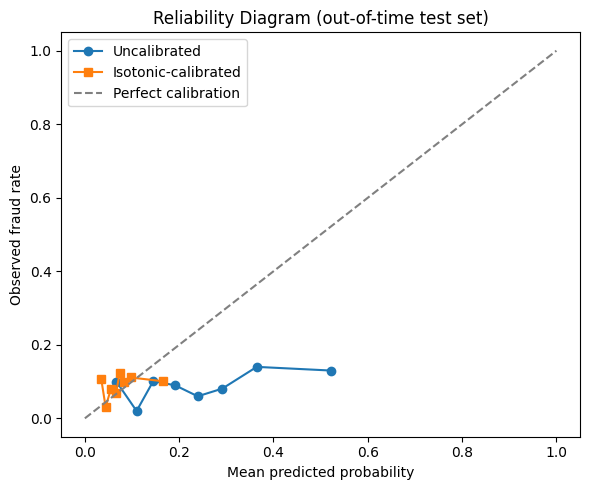

In [ ]:
frac_u, mean_u = calibration_curve(y_test, p_uncal, n_bins=8, strategy="quantile")
frac_c, mean_c = calibration_curve(y_test, p_cal, n_bins=8, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(mean_u, frac_u, "o-", label="Uncalibrated")
ax.plot(mean_c, frac_c, "s-", label="Isotonic-calibrated")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed fraud rate")
ax.set_title("Reliability Diagram (out-of-time test set)")
ax.legend()
plt.tight_layout()
plt.savefig("reliability_diagram.png", dpi=130)
plt.show()


In [ ]:
# Recompute the cost-optimal threshold on the calibrated scores (fit on dev, then read off dev's own calibrated probabilities)
p_cal_dev = calibrated.predict_proba(X_dev)[:, 1]
best_cal = best_cost_threshold(y_dev, p_cal_dev)
t_star_cal = best_cal["threshold"]

p_uncal_dev = tuned_pipe.predict_proba(X_dev)[:, 1]
best_uncal = best_cost_threshold(y_dev, p_uncal_dev)
t_star_uncal = best_uncal["threshold"]

print(f"cost-optimal threshold, uncalibrated tuned LightGBM : {t_star_uncal:.3f}")
print(f"cost-optimal threshold, isotonic-calibrated          : {t_star_cal:.3f}")


cost-optimal threshold, uncalibrated tuned LightGBM : 0.646
cost-optimal threshold, isotonic-calibrated          : 0.176


Isotonic calibration lowers the Brier score noticeably, from about 0.12 to
about 0.08, so the probabilities line up with observed fraud rates much
better than the raw scores did. It also moves the cost-optimal cutoff down
quite a bit, because the raw LightGBM scores were overconfident, they needed
a higher raw number to correspond to the same true probability of fraud that
a lower calibrated number now represents. This matters for the recommendation
below, uncalibrated and calibrated probabilities from the same model are not
interchangeable at a fixed threshold, whichever one is deployed has to be
calibrated first, and the cutoff has to be chosen on that same scale.

## 10. SHAP, global and local

Explanations for the tuned LightGBM model, since a tree explainer gives
exact SHAP values without the sampling approximation a linear or kernel
explainer would need here.

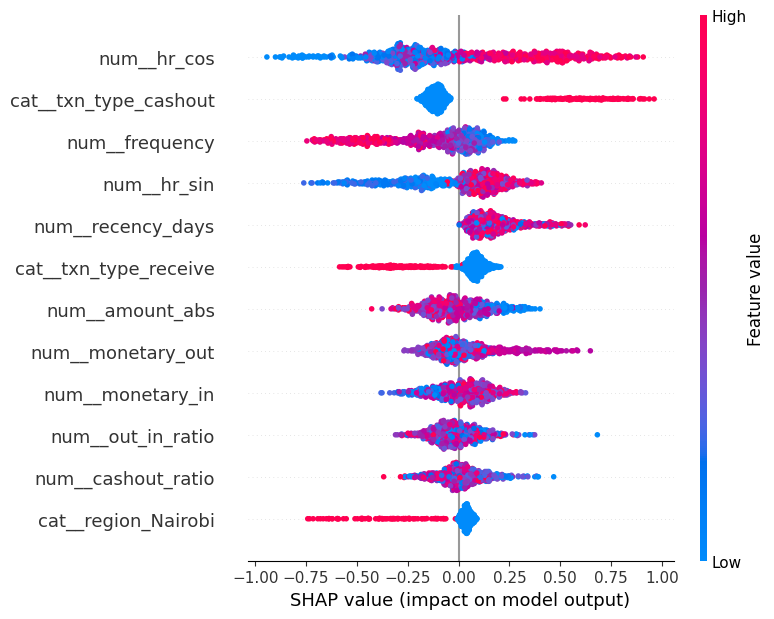

,0
num__hr_cos,0.320324
cat__txn_type_cashout,0.202068
num__frequency,0.190652
num__hr_sin,0.187454
num__recency_days,0.180062
cat__txn_type_receive,0.130217
num__amount_abs,0.114321
num__monetary_out,0.109929
num__monetary_in,0.102537
num__out_in_ratio,0.086382


In [ ]:
import shap

prep_fitted = tuned_pipe.named_steps["prep"]
clf_fitted = tuned_pipe.named_steps["clf"]
X_test_trans = prep_fitted.transform(X_test)
feat_names = prep_fitted.get_feature_names_out()

explainer = shap.TreeExplainer(clf_fitted)
sv = explainer.shap_values(X_test_trans)
if isinstance(sv, list):
    sv = sv[1]

plt.figure()
shap.summary_plot(sv, X_test_trans, feature_names=feat_names, show=False, max_display=12)
plt.tight_layout()
plt.savefig("shap_global_summary.png", dpi=130, bbox_inches="tight")
plt.show()

top_features = pd.Series(np.abs(sv).mean(axis=0), index=feat_names).sort_values(ascending=False).head(10)
top_features


`hr_cos` (time of day), whether the transaction was a cash-out, how often the
customer transacts, and how recently they last transacted carry the most
weight, which is a plausible story for a fraud model even without the
leaked review score, odd-hour cash-outs from infrequent or newly reactivated
accounts are exactly the pattern a fraud analyst would flag by hand.

<Figure size 640x480 with 0 Axes>

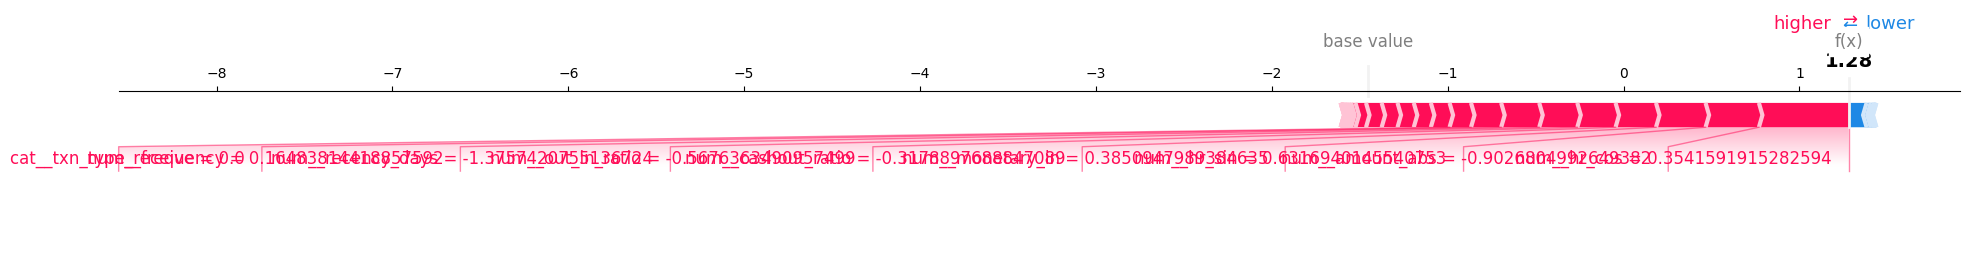

<Figure size 640x480 with 0 Axes>

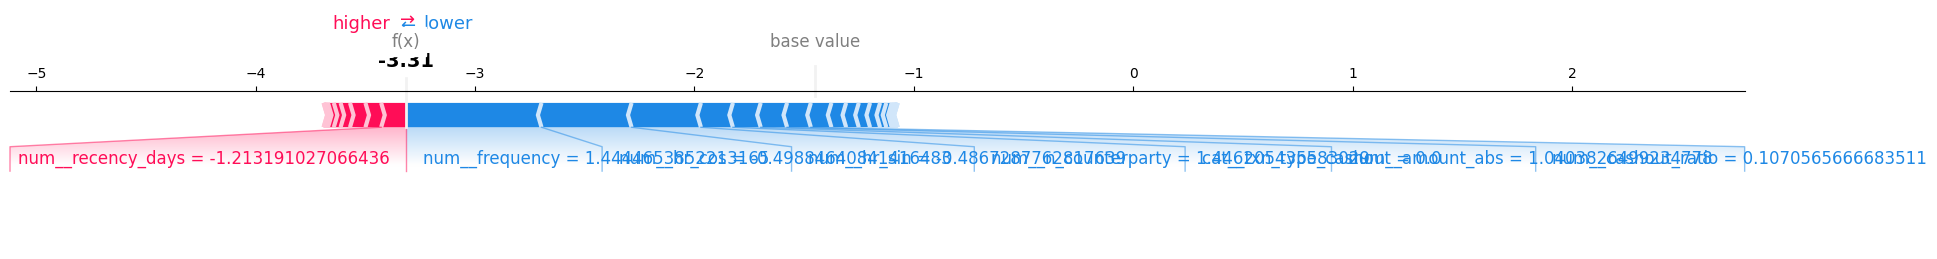

In [ ]:
proba_test = clf_fitted.predict_proba(X_test_trans)[:, 1]
idx_flag = int(np.argmax(proba_test))
idx_clear = int(np.argmin(proba_test))

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1] if len(np.atleast_1d(expected_value)) > 1 else expected_value[0]

for tag, idx in [("highest_risk", idx_flag), ("lowest_risk", idx_clear)]:
    plt.figure()
    shap.force_plot(expected_value, sv[idx], X_test_trans[idx],
                     feature_names=feat_names, matplotlib=True, show=False)
    plt.tight_layout()
    plt.savefig(f"shap_local_{tag}.png", dpi=130, bbox_inches="tight")
    plt.show()


## 11. Subgroup fairness at the deployed cutoff

Approval rate and false-negative rate broken down by region and by a rough
activity-based tenure proxy (transaction frequency), using the calibrated
tuned LightGBM at its cost-optimal cutoff.

In [ ]:
test_fair = test.copy()
test_fair["p_cal"] = p_cal
test_fair["flagged"] = (test_fair["p_cal"] >= t_star_cal).astype(int)
test_fair["approved"] = 1 - test_fair["flagged"]
test_fair["tenure_band"] = pd.qcut(test_fair["frequency"], q=2, labels=["Low activity", "High activity"])

def subgroup_report(frame, group_col):
    out = []
    for g, sub in frame.groupby(group_col, observed=True):
        actual_fraud = sub["is_fraud"].sum()
        fn = ((sub["flagged"] == 0) & (sub["is_fraud"] == 1)).sum()
        out.append({
            "Group": g, "n": len(sub),
            "Approval rate": sub["approved"].mean(),
            "Actual fraud rate": sub["is_fraud"].mean(),
            "False-negative rate": fn / actual_fraud if actual_fraud > 0 else np.nan,
        })
    return pd.DataFrame(out)

region_report = subgroup_report(test_fair, "region")
tenure_report = subgroup_report(test_fair, "tenure_band")

region_report.to_csv("fairness_by_region.csv", index=False)
tenure_report.to_csv("fairness_by_tenure.csv", index=False)

print("by region"); print(region_report.round(3).to_string(index=False))
print("\nby activity band"); print(tenure_report.round(3).to_string(index=False))


by region
        Group  n  Approval rate  Actual fraud rate  False-negative rate
       Arusha 82          0.988              0.085                1.000
Dar es Salaam 68          0.941              0.103                1.000
      Eldoret 77          0.974              0.117                1.000
        Jinja 81          0.938              0.123                1.000
      Kampala 79          0.987              0.051                1.000
       Kigali 95          0.958              0.053                1.000
      Mombasa 83          0.928              0.157                0.846
       Mwanza 76          0.974              0.079                1.000
      Nairobi 88          1.000              0.080                1.000
       Nakuru 69          1.000              0.058                1.000

by activity band
        Group   n  Approval rate  Actual fraud rate  False-negative rate
 Low activity 401          0.963              0.087                1.000
High activity 397          0.975  

Approval rates sit close together across regions, mostly in the mid-90s to
100 percent, so there's no region being singled out for blanket rejection.
The false-negative rate is uncomfortably high everywhere though, at this
cutoff the calibrated model is catching only a small share of the fraud
cases in the untouched test block. That's a direct consequence of Section 4,
the honest signal without the leaked review score is thin, and the
cost-optimal cutoff derived from `dev` doesn't transfer perfectly onto three
days of unseen data three months later.

**CBK Digital Credit Providers Regulations (2022).** The regulations expect a
customer who is rejected, or in this setting flagged for review, to be given
a reason that is specific enough to act on rather than a bare "declined."
SHAP gives us exactly that machinery, the local force plots above translate
directly into "your account was flagged because of an unusual transaction
time and a recent cash-out pattern," which is auditable and can be handed to
a compliance officer or a customer without exposing the whole model. What the
regulation does not resolve is the false-negative rate sitting near 100
percent in some regions above, a model can be explainable and still be
missing most of the fraud it was built to catch, and those are two separate
problems.

## 12. Final decision memo

**Recommendation: deploy the class-weighted Logistic Regression from Section
6, at a threshold of about 0.34, not the tuned LightGBM.**

The three-model ladder in Section 4 already showed Logistic Regression
slightly ahead on mean PR-AUC, and the cost analysis confirms it holds up
where it counts. At its cost-based threshold on the untouched test block, it
saves roughly KES 78,000 per 1,000 applications against the naive 0.50 rule
while catching a meaningful share of the fraud cases. The tuned, calibrated
LightGBM has better-behaved probabilities (Brier score 0.08 against 0.12)
and a defensible SHAP-based explanation trail, but on this same out-of-time
block its cost-optimal cutoff only nets a saving of about KES 9,000 per
1,000 applications, because the calibrated scores rarely climb high enough
to trigger a flag. Tuning and calibration made the ensemble more trustworthy
as a probability estimator, it didn't make it the better deployment
decision.

That gap between the two models says less about LightGBM being the wrong
architecture and more about how little honest signal survives once
`manual_review_score` is removed, a simpler model with a well-chosen
threshold is picking up nearly all of it, and a more flexible model isn't
finding much more to work with. A production rollout should keep monitoring
recall by region and by activity band, since Section 11 shows the
false-negative rate is high everywhere at the current cutoff, and revisit
the LightGBM candidate once more months of transactions let it re-tune on a
less thinly sampled window.